In [14]:
import pandas as pd
import numpy as np
from typing import Tuple, List, Dict
import matplotlib.pyplot as plt


In [29]:
def load_landmarks(filepath: str) -> Dict[int, np.ndarray]:
    landmarks = {}
    df = pd.read_csv(filepath, sep=' ', header=None)
    for _, row in df.iterrows():
        landmark_id = int(row[0])
        x, y = row[1], row[2]
        landmarks[landmark_id] = np.array([x, y])
    return landmarks


def load_sensor_data(filepath: str) -> List[Dict]:
    df = pd.read_csv(filepath, sep=' ', header=None)
    data = []
    current_step = None
    
    for _, row in df.iterrows():
        if row[0] == 'ODOMETRY':
            # Сохраняем предыдущий шаг перед созданием нового
            if current_step is not None:
                data.append(current_step)
            current_step = {
                'odometry': np.array([row[1], row[2], row[3]]),
                'sensors': []
            }
        elif row[0] == 'SENSOR' and current_step is not None:
            landmark_id = int(row[1])
            distance = row[2]
            bearing = row[3]
            current_step['sensors'].append({
                'landmark_id': landmark_id,
                'distance': distance,
                'bearing': bearing
            })
    
    # Не забываем добавить последний шаг
    if current_step is not None:
        data.append(current_step)
    
    return data


def parse_odometry_commands(data: List[Dict]) -> List[np.ndarray]:
    """Извлекает только команды одометрии из загруженных данных"""
    return [step['odometry'] for step in data if step is not None and 'odometry' in step]

def motion_model(state: np.ndarray, control: np.ndarray) -> np.ndarray:
    """
    Модель движения робота (одометрия).
    """
    x, y, theta = state
    delta_r1, delta_t, delta_r2 = control
    
    x_new = x + delta_t * np.cos(theta + delta_r1)
    y_new = y + delta_t * np.sin(theta + delta_r1)
    theta_new = theta + delta_r1 + delta_r2
    
    # # Нормализация угла
    # theta_new = np.arctan2(np.sin(theta_new), np.cos(theta_new))
    return np.array([x_new, y_new, theta_new])

D_ex = 0.2
D_ey = 0.2
D_e_theta = 0.2
Q = np.array([
    [D_ex, 0, 0],
    [0, D_ey, 0],
    [0, 0, D_e_theta],
])

odometry_and_sensor_data = load_sensor_data("data_files/sensor_data_ekf.dat")
landmarks = load_landmarks("data_files/landmarks.dat")
print(odometry_and_sensor_data[0])
print(landmarks)

{'odometry': array([0.10137369, 0.09962523, 0.00086224]), 'sensors': [{'landmark_id': 1, 'distance': 2.29725290252, 'bearing': 0.353956815014}, {'landmark_id': 2, 'distance': 4.01825728983, 'bearing': 1.51507415344}]}
{1: array([2, 1], dtype=int64), 2: array([0, 4], dtype=int64), 3: array([2, 7], dtype=int64), 4: array([9, 2], dtype=int64), 5: array([10,  5], dtype=int64), 6: array([9, 8], dtype=int64), 7: array([5, 5], dtype=int64), 8: array([5, 3], dtype=int64), 9: array([5, 9], dtype=int64)}


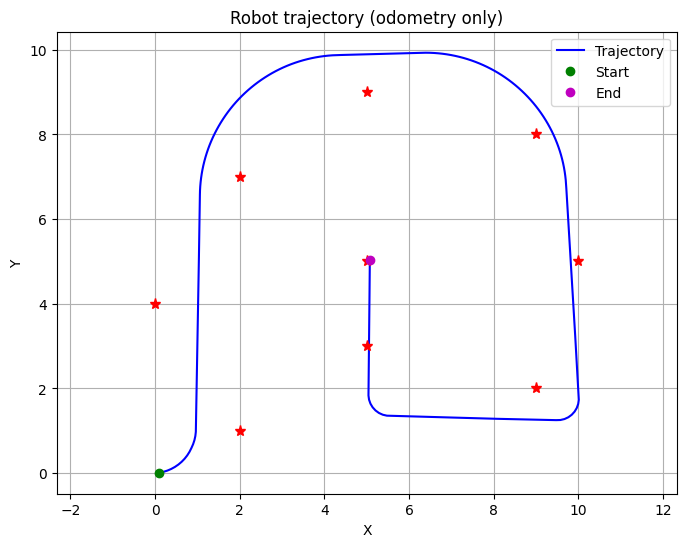

Start: (0.099, 0.010)
End: (5.074, 5.033)


In [31]:
# Начальное состояние
initial_state = np.array([0.0, 0.0, 0.0])
state = initial_state.copy()
odometry_commands = parse_odometry_commands(odometry_and_sensor_data)
trajectory = []
for odo_com in odometry_commands:
    state = motion_model(state, odo_com)
    trajectory.append(state.copy())
trajectory = np.array(trajectory)

# Минимальная визуализация траектории
plt.figure(figsize=(8, 6))

# Траектория
plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-', label='Trajectory')

# Ориентиры
for lid, (lx, ly) in landmarks.items():
    plt.plot(lx, ly, 'r*', markersize=8)

# Старт и финиш
plt.plot(trajectory[0, 0], trajectory[0, 1], 'go', label='Start')
plt.plot(trajectory[-1, 0], trajectory[-1, 1], 'mo', label='End')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Robot trajectory (odometry only)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Просто вывод координат для проверки
print(f"Start: ({trajectory[0,0]:.3f}, {trajectory[0,1]:.3f})")
print(f"End: ({trajectory[-1,0]:.3f}, {trajectory[-1,1]:.3f})")

# EKF

In [32]:
def motion_jacobian(state: np.ndarray, control: np.ndarray) -> np.ndarray:
    _, _, theta = state
    delta_r1, delta_t, _ = control
    
    theta_mid = theta + delta_r1
    
    F = np.array([
        [1, 0, -delta_t * np.sin(theta_mid)],
        [0, 1, delta_t * np.cos(theta_mid)],
        [0, 0, 1]
    ])
    
    return F

def measurement_model(state: np.ndarray, landmark: np.ndarray) -> np.ndarray:
    """Расстояние и пеленг до ориентира"""
    x, y, theta = state
    lx, ly = landmark
    
    dx = lx - x
    dy = ly - y
    
    distance = np.sqrt(dx**2 + dy**2)
    bearing = np.arctan2(dy, dx) - theta
    bearing = np.arctan2(np.sin(bearing), np.cos(bearing))
    
    return np.array([distance, bearing])


def measurement_jacobian(state: np.ndarray, landmark: np.ndarray) -> np.ndarray:
    """Якобиан модели измерения"""
    x, y, theta = state
    lx, ly = landmark
    
    dx = lx - x
    dy = ly - y
    q = dx**2 + dy**2
    sqrt_q = np.sqrt(q)
    
    if sqrt_q < 1e-6:
        sqrt_q = 1e-6
        q = 1e-12
    
    H = np.array([
        [-dx / sqrt_q, -dy / sqrt_q, 0],
        [dy / q, -dx / q, -1]
    ])
    
    return H

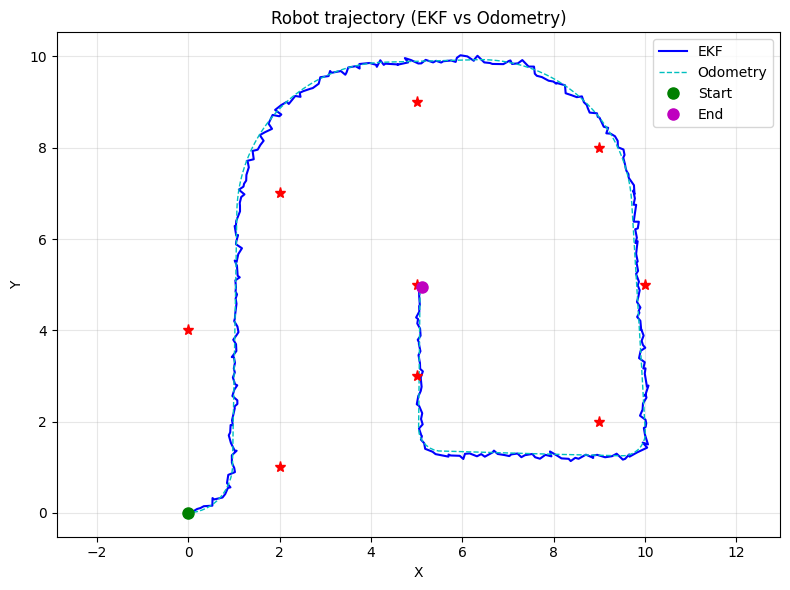

EKF Start: (0.000, 0.000)
EKF End:   (5.111, 4.948)
Odom End:  (5.074, 5.033)


In [33]:
D_ex = 0.2
D_ey = 0.2
D_e_theta = 0.2
Q = np.diag([D_ex, D_ey, D_e_theta])

D_r = 0.2      # дисперсия расстояния
D_bearing = 0.2  # дисперсия пеленга
R = np.diag([D_r, D_bearing])

# Начальное состояние
initial_state = np.array([0.0, 0.0, 0.0])
P = np.diag([0.1, 0.1, 0.1])

# Загрузка данных
odometry_and_sensor_data = load_sensor_data("data_files/sensor_data_ekf.dat")
landmarks = load_landmarks("data_files/landmarks.dat")

# Хранение траектории
ekf_trajectory = [initial_state.copy()]
P_history = [P.copy()]

state = initial_state.copy()

for step in odometry_and_sensor_data:
    # Прогноз
    control = step['odometry']
    F = motion_jacobian(state, control)
    state = motion_model(state, control)
    P = F @ P @ F.T + Q
    
    # Коррекция по сенсорам
    sensors = step['sensors']
    if len(sensors) > 0:
        # Собираем все измерения
        z = []
        H_list = []
        
        for sensor in sensors:
            lid = sensor['landmark_id']
            if lid not in landmarks:
                continue
            
            landmark = landmarks[lid]
            z_meas = np.array([sensor['distance'], sensor['bearing']])
            z_pred = measurement_model(state, landmark)
            H = measurement_jacobian(state, landmark)
            
            z.append(z_meas - z_pred)
            H_list.append(H)
        
        if len(z) > 0:
            z = np.concatenate(z)
            H = np.vstack(H_list)
            R_full = np.kron(np.eye(len(z) // 2), R)
            
            # Нормализация углов в инновации
            for i in range(1, len(z), 2):
                z[i] = np.arctan2(np.sin(z[i]), np.cos(z[i]))
            
            # Коэффициент Калмана
            S = H @ P @ H.T + R_full
            K = P @ H.T @ np.linalg.inv(S)
            
            # Обновление
            state = state + K @ z
            state[2] = np.arctan2(np.sin(state[2]), np.cos(state[2]))
            P = (np.eye(3) - K @ H) @ P
    
    ekf_trajectory.append(state.copy())
    P_history.append(P.copy())

ekf_trajectory = np.array(ekf_trajectory)


plt.figure(figsize=(8, 6))

# Траектория EKF
plt.plot(ekf_trajectory[:-1, 0], ekf_trajectory[:-1, 1], 'b-', linewidth=1.5, label='EKF')

# Траектория по одометрии
plt.plot(trajectory[:, 0], trajectory[:, 1], 'c--', linewidth=1, label='Odometry')

# Ориентиры
for lid, (lx, ly) in landmarks.items():
    plt.plot(lx, ly, 'r*', markersize=8)

# Старт и финиш
plt.plot(ekf_trajectory[0, 0], ekf_trajectory[0, 1], 'go', markersize=8, label='Start')
plt.plot(ekf_trajectory[-1, 0], ekf_trajectory[-1, 1], 'mo', markersize=8, label='End')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Robot trajectory (EKF vs Odometry)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Вывод координат
print(f"EKF Start: ({ekf_trajectory[0,0]:.3f}, {ekf_trajectory[0,1]:.3f})")
print(f"EKF End:   ({ekf_trajectory[-1,0]:.3f}, {ekf_trajectory[-1,1]:.3f})")
print(f"Odom End:  ({trajectory[-1,0]:.3f}, {trajectory[-1,1]:.3f})")

# UKF

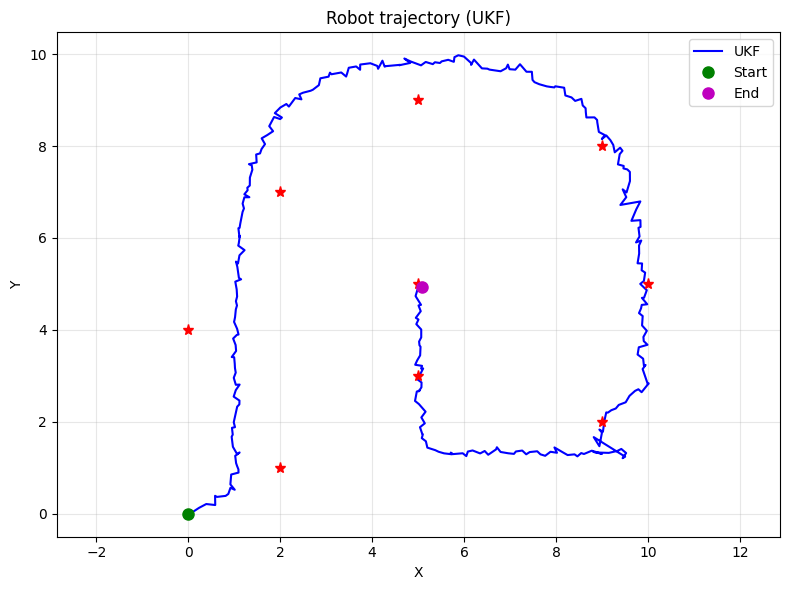

Start: (0.000, 0.000)
End:   (5.078, 4.935)


In [ ]:
def measurement_model(state: np.ndarray, landmarks_dict: Dict[int, np.ndarray], 
                      landmark_ids: List[int]) -> np.ndarray:
    """
    h(x, landmarks) - модель измерения
    Возвращает расстояния до указанных ориентиров
    """
    x, y, _ = state
    measurements = []
    
    for lid in landmark_ids:
        if lid in landmarks_dict:
            lx, ly = landmarks_dict[lid]
            distance = np.sqrt((x - lx)**2 + (y - ly)**2)
            measurements.append(distance)
    
    return np.array(measurements)

# ============================================================================
# UKF
# ============================================================================

# Параметры UKF
alpha = 5e-2
kappa = 0
beta = 2

# Шумы
Q = np.diag([0.2, 0.2, 0.2])      # шум движения
R_val = 0.2                        # шум измерения расстояния

# Начальное состояние
X = np.array([0.0, 0.0, 0.0])
P = np.diag([0.1, 0.1, 0.1])

# Загрузка данных
landmarks = load_landmarks("data_files/landmarks.dat")
sensor_data = load_sensor_data("data_files/sensor_data_ekf.dat")

# Размерность состояния
n = len(X)
lam = alpha**2 * (n + kappa) - n

# Весовые коэффициенты
W_m = np.ones(2 * n + 1) / (2 * (n + lam))
W_c = np.ones(2 * n + 1) / (2 * (n + lam))
W_m[0] = lam / (n + lam)
W_c[0] = lam / (n + lam) + (1 - alpha**2 + beta)

# История траектории
trajectory = [X.copy()]
P_history = [P.copy()]

for step in sensor_data:
    control = step['odometry']
    sensors = step['sensors']
    
    # =========================================================================
    # ПРОГНОЗ
    # =========================================================================
    
    # Генерация сигма-точек
    try:
        sqrt_P = np.linalg.cholesky((n + lam) * P)
    except np.linalg.LinAlgError:
        sqrt_P = np.linalg.cholesky((n + lam) * P + 1e-6 * np.eye(n))
    
    sigma_points = np.zeros((n, 2 * n + 1))
    sigma_points[:, 0] = X
    for i in range(n):
        sigma_points[:, i + 1] = X + sqrt_P[:, i]
        sigma_points[:, n + i + 1] = X - sqrt_P[:, i]
    
    # Пропагация через модель движения
    sigma_points_pred = np.zeros_like(sigma_points)
    for i in range(2 * n + 1):
        sigma_points_pred[:, i] = motion_model(sigma_points[:, i], control)
    
    # Предсказанное среднее
    X_pred = np.sum(W_m * sigma_points_pred, axis=1)
    
    # Предсказанная ковариация
    P_pred = Q.copy()
    for i in range(2 * n + 1):
        diff = sigma_points_pred[:, i] - X_pred
        P_pred += W_c[i] * np.outer(diff, diff)
    
    # =========================================================================
    # КОРРЕКЦИЯ
    # =========================================================================
    
    if len(sensors) > 0:
        landmark_ids = [s['landmark_id'] for s in sensors]
        measurements = np.array([s['distance'] for s in sensors])
        
        # Генерация сигма-точек для коррекции
        try:
            sqrt_P_pred = np.linalg.cholesky((n + lam) * P_pred)
        except np.linalg.LinAlgError:
            sqrt_P_pred = np.linalg.cholesky((n + lam) * P_pred + 1e-6 * np.eye(n))
        
        sigma_points_corr = np.zeros((n, 2 * n + 1))
        sigma_points_corr[:, 0] = X_pred
        for i in range(n):
            sigma_points_corr[:, i + 1] = X_pred + sqrt_P_pred[:, i]
            sigma_points_corr[:, n + i + 1] = X_pred - sqrt_P_pred[:, i]
        
        # Предсказанные измерения для каждой сигма-точки
        Z_pred = np.zeros((len(landmark_ids), 2 * n + 1))
        for i in range(2 * n + 1):
            Z_pred[:, i] = measurement_model(sigma_points_corr[:, i], landmarks, landmark_ids)
        
        # Среднее предсказанных измерений
        z_mean = np.sum(W_m * Z_pred, axis=1)
        
        # Ковариация измерений
        S = R_val * np.eye(len(landmark_ids))
        for i in range(2 * n + 1):
            diff_z = Z_pred[:, i] - z_mean
            S += W_c[i] * np.outer(diff_z, diff_z)
        
        # Кросс-ковариация
        C = np.zeros((n, len(landmark_ids)))
        for i in range(2 * n + 1):
            diff_x = sigma_points_corr[:, i] - X_pred
            diff_z = Z_pred[:, i] - z_mean
            C += W_c[i] * np.outer(diff_x, diff_z)
        
        # Коэффициент Калмана
        K = C @ np.linalg.inv(S)
        
        # Обновление состояния
        innovation = measurements - z_mean
        X = X_pred + K @ innovation
        
        # Обновление ковариации
        P = P_pred - K @ S @ K.T
    else:
        X = X_pred
        P = P_pred
    
    trajectory.append(X.copy())
    P_history.append(P.copy())

trajectory = np.array(trajectory)


plt.figure(figsize=(8, 6))

# Траектория UKF
plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=1.5, label='UKF')

# Ориентиры
for lid, (lx, ly) in landmarks.items():
    plt.plot(lx, ly, 'r*', markersize=8)

# Старт и финиш
plt.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=8, label='Start')
plt.plot(trajectory[-1, 0], trajectory[-1, 1], 'mo', markersize=8, label='End')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Robot trajectory (UKF)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Вывод координат
print(f"Start: ({trajectory[0,0]:.3f}, {trajectory[0,1]:.3f})")
print(f"End:   ({trajectory[-1,0]:.3f}, {trajectory[-1,1]:.3f})")